# Feature Matrix EDA — H-Spot Bangkok

This notebook performs a thorough exploratory analysis of all four feature groups in the master feature matrix. The goal is to understand distributions, identify outliers, and discover patterns that will guide modeling decisions.

**Feature Groups:**
1. 🛣️ Road Attributes (`feat_road`)
2. 🚨 Accident Features (`feat_accidents`)
3. 🏙️ Spatial Context (`feat_spatial`)
4. 🚗 Probe/Speed Data (`feat_probe`)

In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
plt.rcParams.update({'figure.figsize': (14, 7), 'axes.titlesize': 14, 'axes.labelsize': 12})
sns.set_palette('viridis')

# ── Load data ──────────────────────────────────────────
MATRIX = '../../data/processed/features/feature_matrix.parquet'
ROADS_GEO = '../../data/processed/road_segments.gpkg'

df = pd.read_parquet(MATRIX)
gdf_roads = gpd.read_file(ROADS_GEO)
gdf = gdf_roads[['segment_id','geometry','name']].merge(df, on='segment_id', how='inner')

# Derived helper columns
df['has_accident'] = (df['acc_total'] > 0).astype(int)
df['has_probe']    = df['probe_count'] > 0

print(f'Matrix: {df.shape[0]:,} segments × {df.shape[1]} features')
df.head(3)

Matrix: 276,062 segments × 31 features


,segment_id,highway,highway_rank,lanes,length_m,acc_minor,acc_serious,acc_fatal,acc_sev_3,acc_total,...,dist_mall_m,building_density_200m,probe_count,speed_mean,speed_std,speed_p10,speed_p90,pct_below_20kmh,has_accident,has_probe
0,0,unclassified,1,2,100.0,0,0,0,0,0,...,15772.0,0,0,NaN,NaN,NaN,NaN,NaN,0,False
1,1,unclassified,1,2,100.0,0,0,0,0,0,...,15772.7,0,0,NaN,NaN,NaN,NaN,NaN,0,False
2,2,unclassified,1,2,100.0,0,0,0,0,0,...,15729.0,0,0,NaN,NaN,NaN,NaN,NaN,0,False


---
## Part 1 — 🛣️ Road Attributes
*(highway, highway_rank, lanes, length_m)*

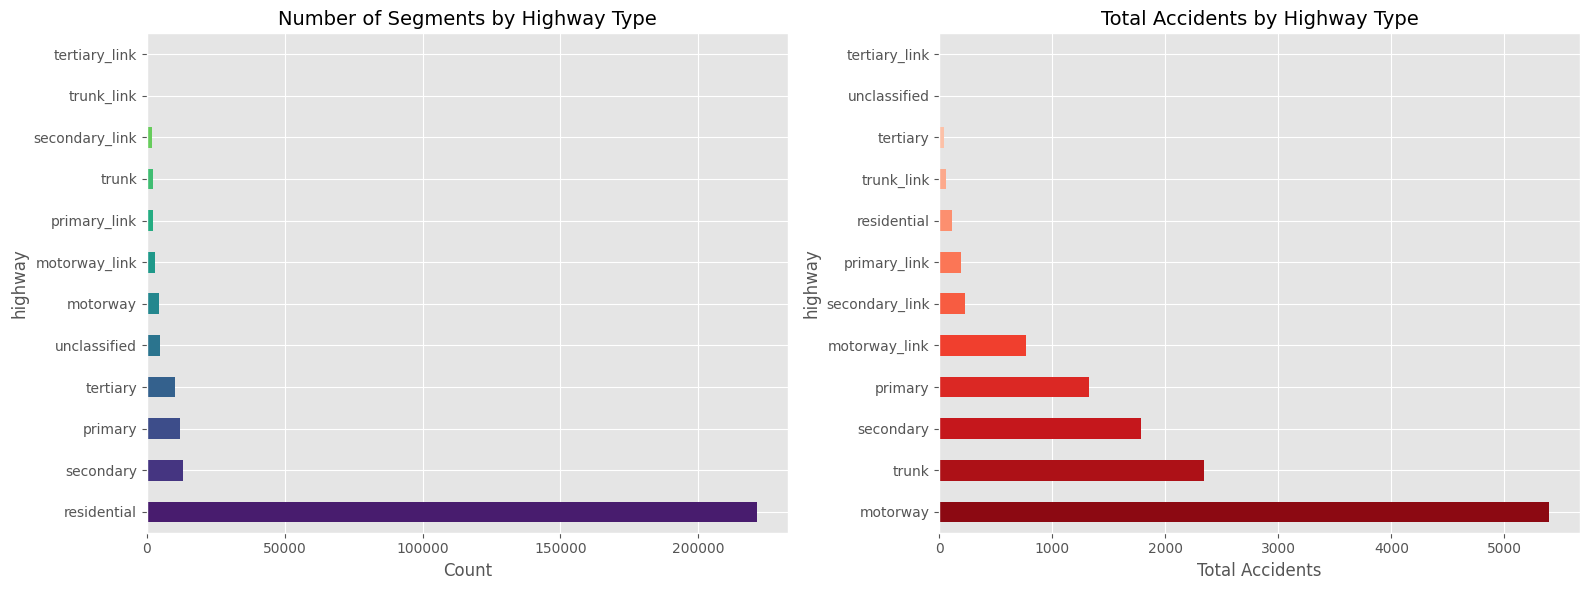

In [3]:
# 1-A: Road type distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

hw_counts = df['highway'].value_counts()
hw_counts.plot(kind='barh', ax=axes[0], color=sns.color_palette('viridis', len(hw_counts)))
axes[0].set_title('Number of Segments by Highway Type')
axes[0].set_xlabel('Count')

# Accident rate per highway type
acc_rate = df.groupby('highway')['acc_total'].sum().sort_values(ascending=False)
acc_rate.plot(kind='barh', ax=axes[1], color=sns.color_palette('Reds_r', len(acc_rate)))
axes[1].set_title('Total Accidents by Highway Type')
axes[1].set_xlabel('Total Accidents')

plt.tight_layout()
plt.show()

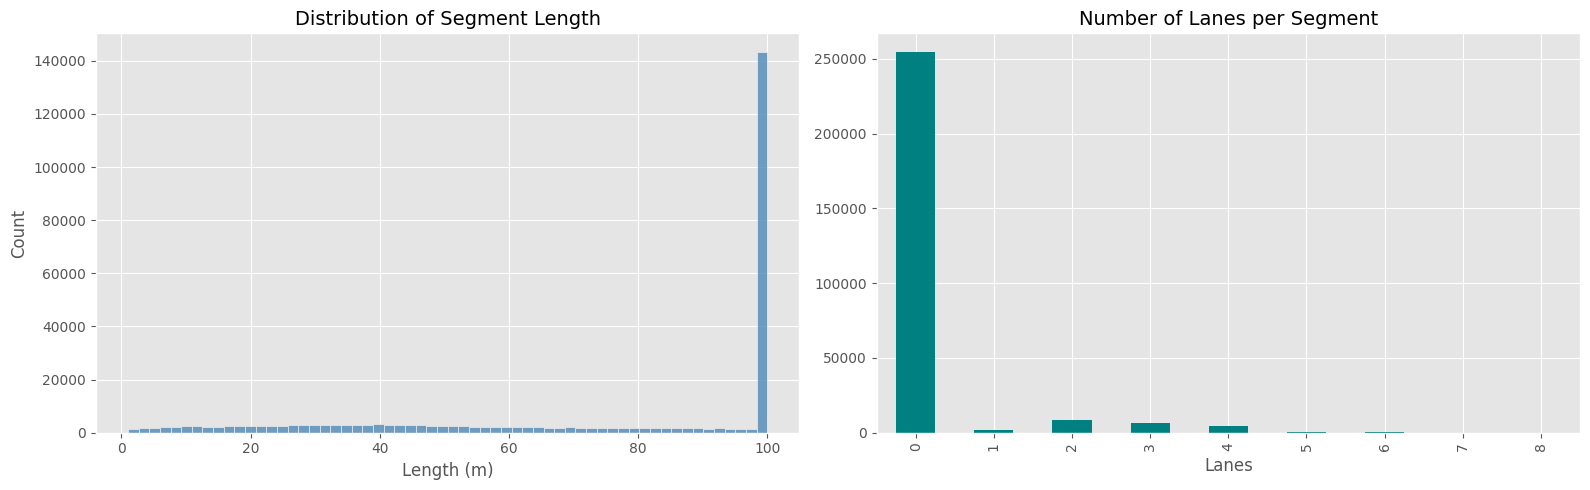


Segment Length:
  Mean: 74.1m  |  Median: 100.0m  |  Max: 100.0m
Lanes:
lanes
0    254268
2      8221
3      6446
4      4322
1      1876
5       592
6       277
7        42
8        18


In [4]:
# 1-B: Segment length distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(df['length_m'], bins=60, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Segment Length')
axes[0].set_xlabel('Length (m)')

# Lanes distribution
df['lanes'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='teal')
axes[1].set_title('Number of Lanes per Segment')
axes[1].set_xlabel('Lanes')

plt.tight_layout()
plt.show()

print(f"\nSegment Length:\n  Mean: {df['length_m'].mean():.1f}m  |  Median: {df['length_m'].median():.1f}m  |  Max: {df['length_m'].max():.1f}m")
print(f"Lanes:\n{df['lanes'].value_counts().to_string()}")

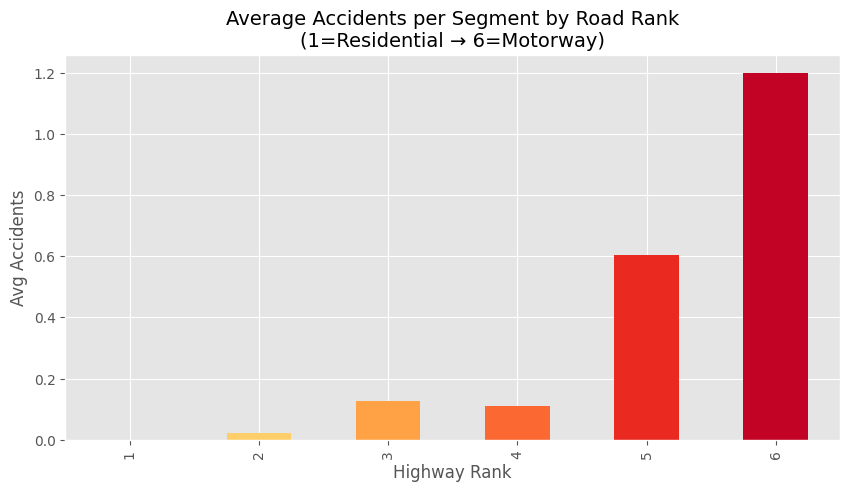

              segments  total_accidents  acc_per_segment
highway_rank                                            
1               226264              117           0.0005
2                12051              275           0.0228
3                15512             1978           0.1275
4                12572             1384           0.1101
5                 5157             3107           0.6025
6                 4506             5399           1.1982


In [5]:
# 1-C: Accident Rate by Highway Rank
acc_by_rank = df.groupby('highway_rank').agg(
    segments=('segment_id','count'),
    total_accidents=('acc_total','sum')
).assign(acc_per_segment=lambda x: x['total_accidents'] / x['segments'])

fig, ax = plt.subplots(figsize=(10, 5))
acc_by_rank['acc_per_segment'].plot(kind='bar', ax=ax, color=sns.color_palette('YlOrRd', 6))
ax.set_title('Average Accidents per Segment by Road Rank\n(1=Residential → 6=Motorway)')
ax.set_xlabel('Highway Rank')
ax.set_ylabel('Avg Accidents')
plt.show()

print(acc_by_rank.round(4))

---
## Part 2 — 🚨 Accident Features
*(acc_total, severity, temporal bins, monsoon)*

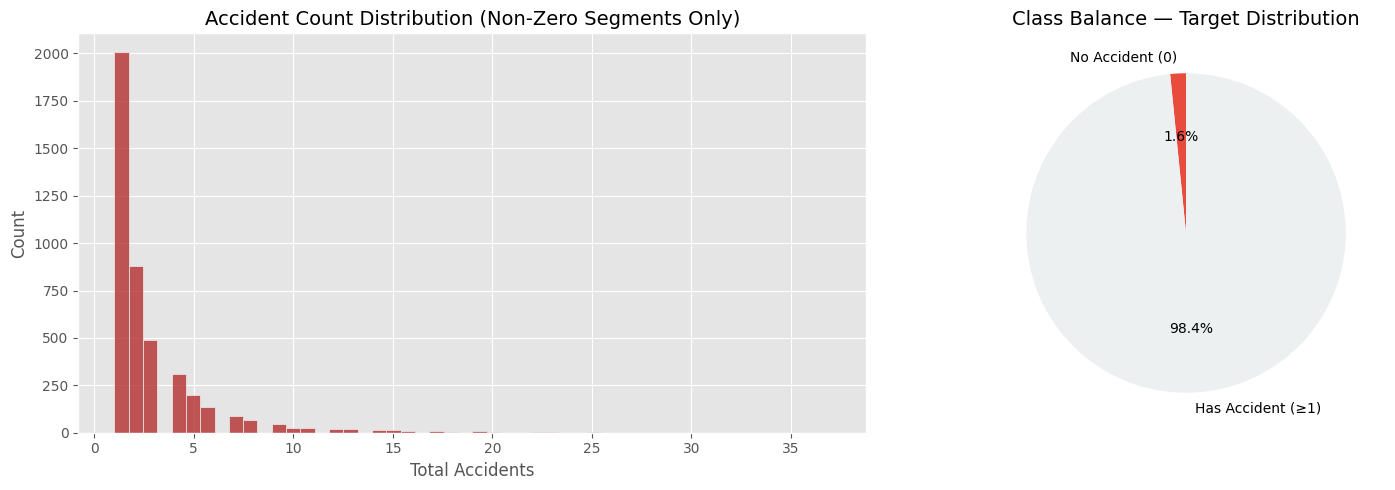

Segments with at least 1 accident: 4,385 (1.6%)
Max accidents on a single segment: 37


In [6]:
# 2-A: Class imbalance — the core problem
zero_pct = (df['acc_total'] == 0).mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(df[df['acc_total'] > 0]['acc_total'], bins=50, ax=axes[0], color='firebrick')
axes[0].set_title('Accident Count Distribution (Non-Zero Segments Only)')
axes[0].set_xlabel('Total Accidents')

axes[1].pie([100-zero_pct, zero_pct], labels=['No Accident (0)', 'Has Accident (≥1)'],
            autopct='%1.1f%%', colors=['#e74c3c','#ecf0f1'], startangle=90)
axes[1].set_title('Class Balance — Target Distribution')

plt.tight_layout()
plt.show()

print(f'Segments with at least 1 accident: {(df["acc_total"]>0).sum():,} ({100-zero_pct:.1f}%)')
print(f'Max accidents on a single segment: {df["acc_total"].max()}')

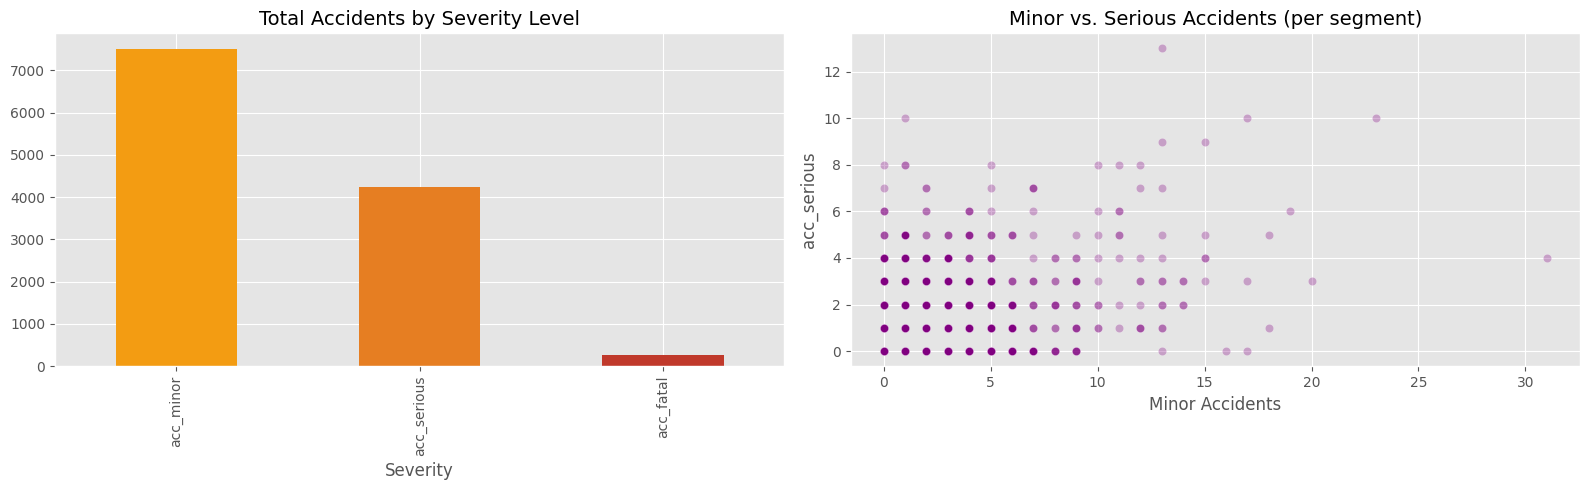

In [7]:
# 2-B: Severity breakdown
sev_cols = ['acc_minor', 'acc_serious', 'acc_fatal']
sev_totals = df[sev_cols].sum()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sev_totals.plot(kind='bar', ax=axes[0], color=['#f39c12','#e67e22','#c0392b'])
axes[0].set_title('Total Accidents by Severity Level')
axes[0].set_xlabel('Severity')

# Per segment average (for segments with ≥1 accident)
acc_df = df[df['acc_total'] > 0]
sns.scatterplot(data=acc_df.sample(min(3000, len(acc_df))), x='acc_minor', y='acc_serious',
                alpha=0.3, ax=axes[1], color='purple')
axes[1].set_title('Minor vs. Serious Accidents (per segment)')
axes[1].set_xlabel('Minor Accidents')

plt.tight_layout()
plt.show()

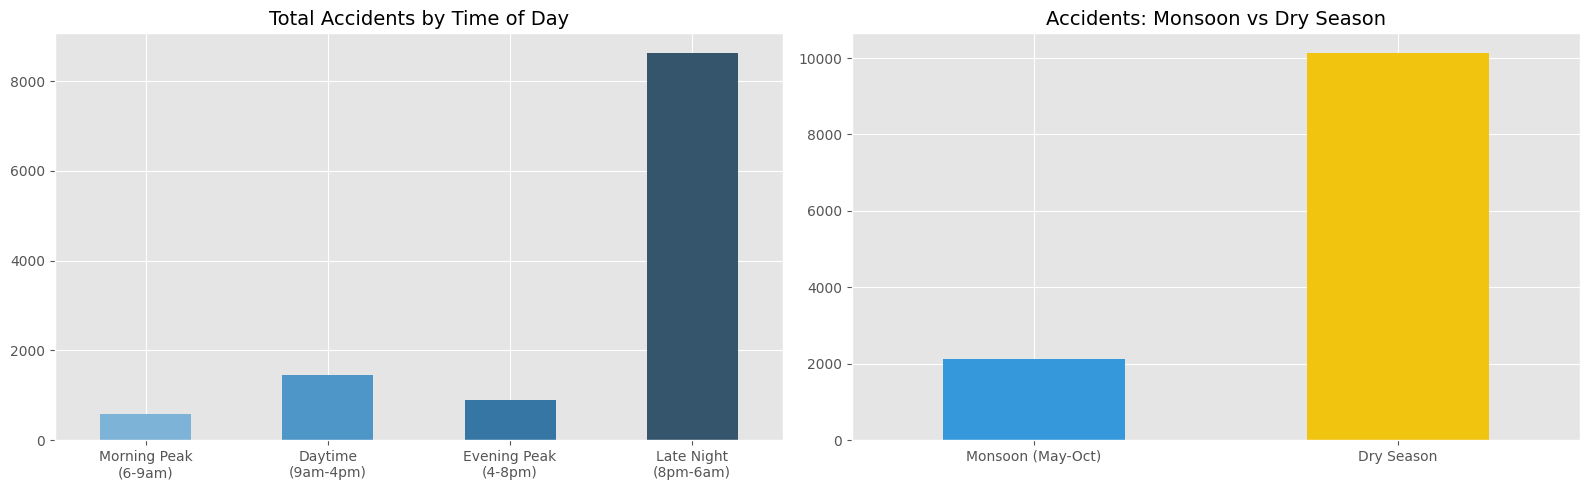

In [8]:
# 2-C: Temporal patterns
time_cols = ['acc_morning_peak', 'acc_daytime', 'acc_evening_peak', 'acc_late_night']
time_totals = df[time_cols].sum().rename({
    'acc_morning_peak': 'Morning Peak\n(6-9am)',
    'acc_daytime': 'Daytime\n(9am-4pm)',
    'acc_evening_peak': 'Evening Peak\n(4-8pm)',
    'acc_late_night': 'Late Night\n(8pm-6am)'
})

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

time_totals.plot(kind='bar', ax=axes[0], color=sns.color_palette('Blues_d', 4))
axes[0].set_title('Total Accidents by Time of Day')
axes[0].tick_params(axis='x', rotation=0)

monsoon_totals = df[['acc_monsoon','acc_dry']].sum().rename({'acc_monsoon':'Monsoon (May-Oct)','acc_dry':'Dry Season'})
monsoon_totals.plot(kind='bar', ax=axes[1], color=['#3498db','#f1c40f'])
axes[1].set_title('Accidents: Monsoon vs Dry Season')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

---
## Part 3 — 🏙️ Spatial Context Features
*(dist_intersection_m, poi_count_200m, building_density_200m, dist_school/hospital/fuel/mall)*

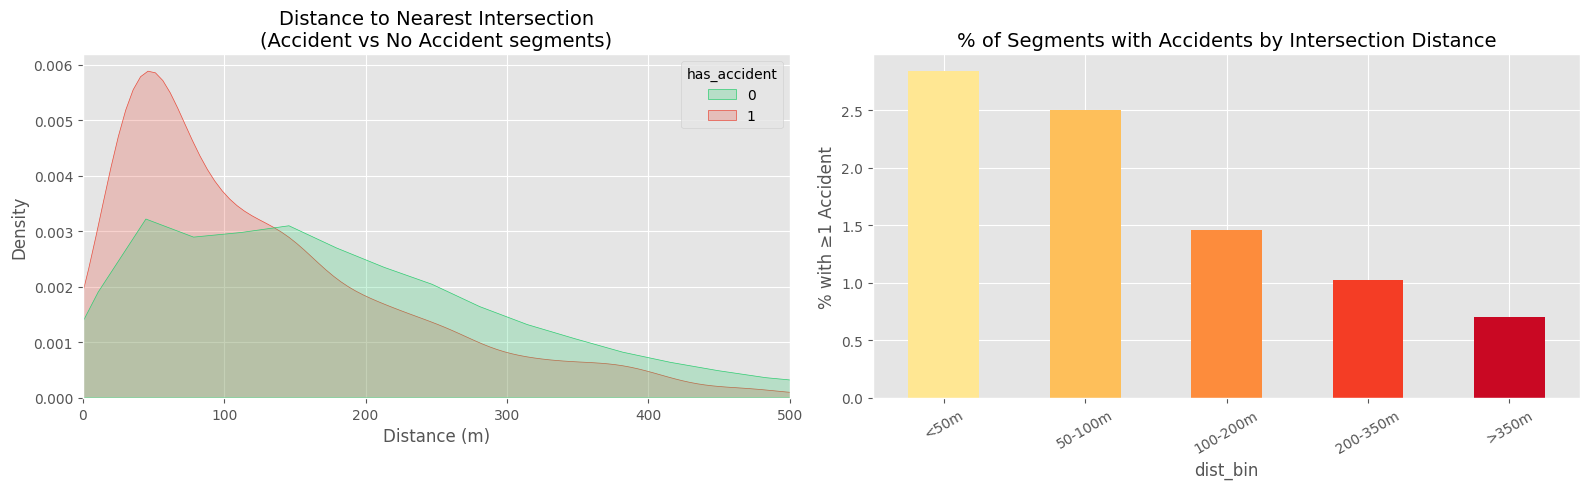

In [9]:
# 3-A: Distance to intersection vs accident risk
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.kdeplot(data=df, x='dist_intersection_m', hue='has_accident',
            fill=True, common_norm=False, ax=axes[0], palette=['#2ecc71','#e74c3c'])
axes[0].set_xlim(0, 500)
axes[0].set_title('Distance to Nearest Intersection\n(Accident vs No Accident segments)')
axes[0].set_xlabel('Distance (m)')

# Binned distance analysis
df['dist_bin'] = pd.cut(df['dist_intersection_m'], bins=[0,50,100,200,350,2000],
                         labels=['<50m','50-100m','100-200m','200-350m','>350m'])
acc_by_dist = df.groupby('dist_bin', observed=True)['has_accident'].mean() * 100
acc_by_dist.plot(kind='bar', ax=axes[1], color=sns.color_palette('YlOrRd', 5))
axes[1].set_title('% of Segments with Accidents by Intersection Distance')
axes[1].set_ylabel('% with ≥1 Accident')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

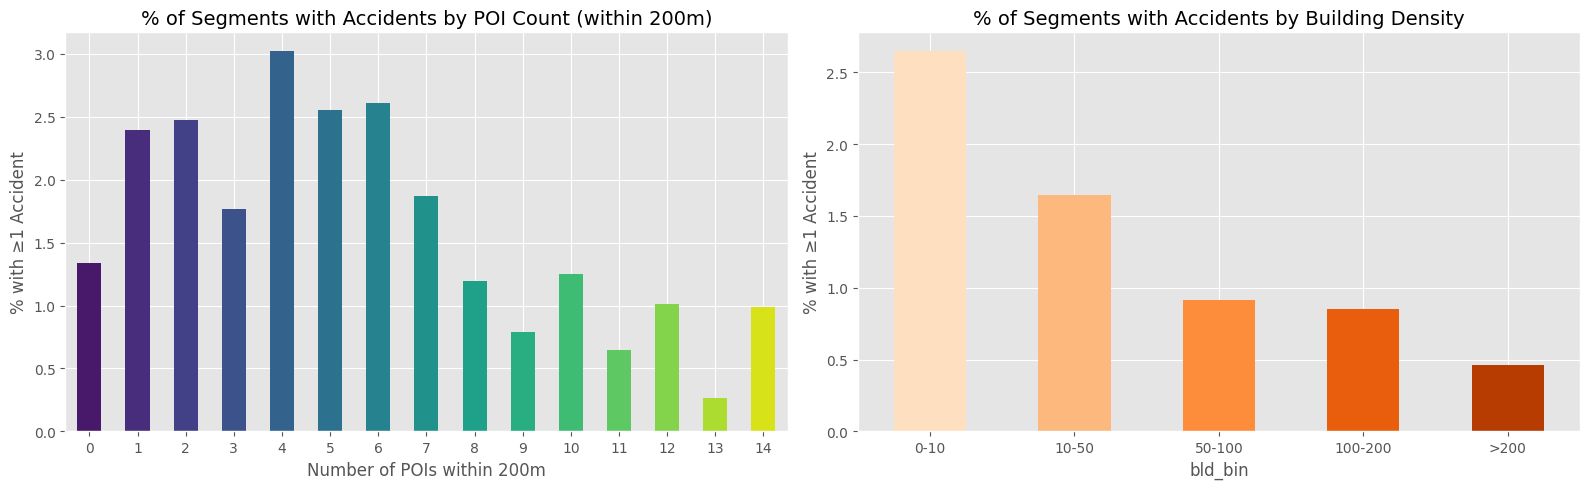

In [10]:
# 3-B: POI count and building density
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# POI count vs accident rate
poi_acc = df.groupby('poi_count_200m', observed=True)['has_accident'].mean() * 100
poi_acc.iloc[:15].plot(kind='bar', ax=axes[0], color=sns.color_palette('viridis', 15))
axes[0].set_title('% of Segments with Accidents by POI Count (within 200m)')
axes[0].set_ylabel('% with ≥1 Accident')
axes[0].set_xlabel('Number of POIs within 200m')
axes[0].tick_params(axis='x', rotation=0)

# Building density vs accident rate (binned)
df['bld_bin'] = pd.cut(df['building_density_200m'], bins=[0,10,50,100,200,2000],
                        labels=['0-10','10-50','50-100','100-200','>200'])
bld_acc = df.groupby('bld_bin', observed=True)['has_accident'].mean() * 100
bld_acc.plot(kind='bar', ax=axes[1], color=sns.color_palette('Oranges', 5))
axes[1].set_title('% of Segments with Accidents by Building Density')
axes[1].set_ylabel('% with ≥1 Accident')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

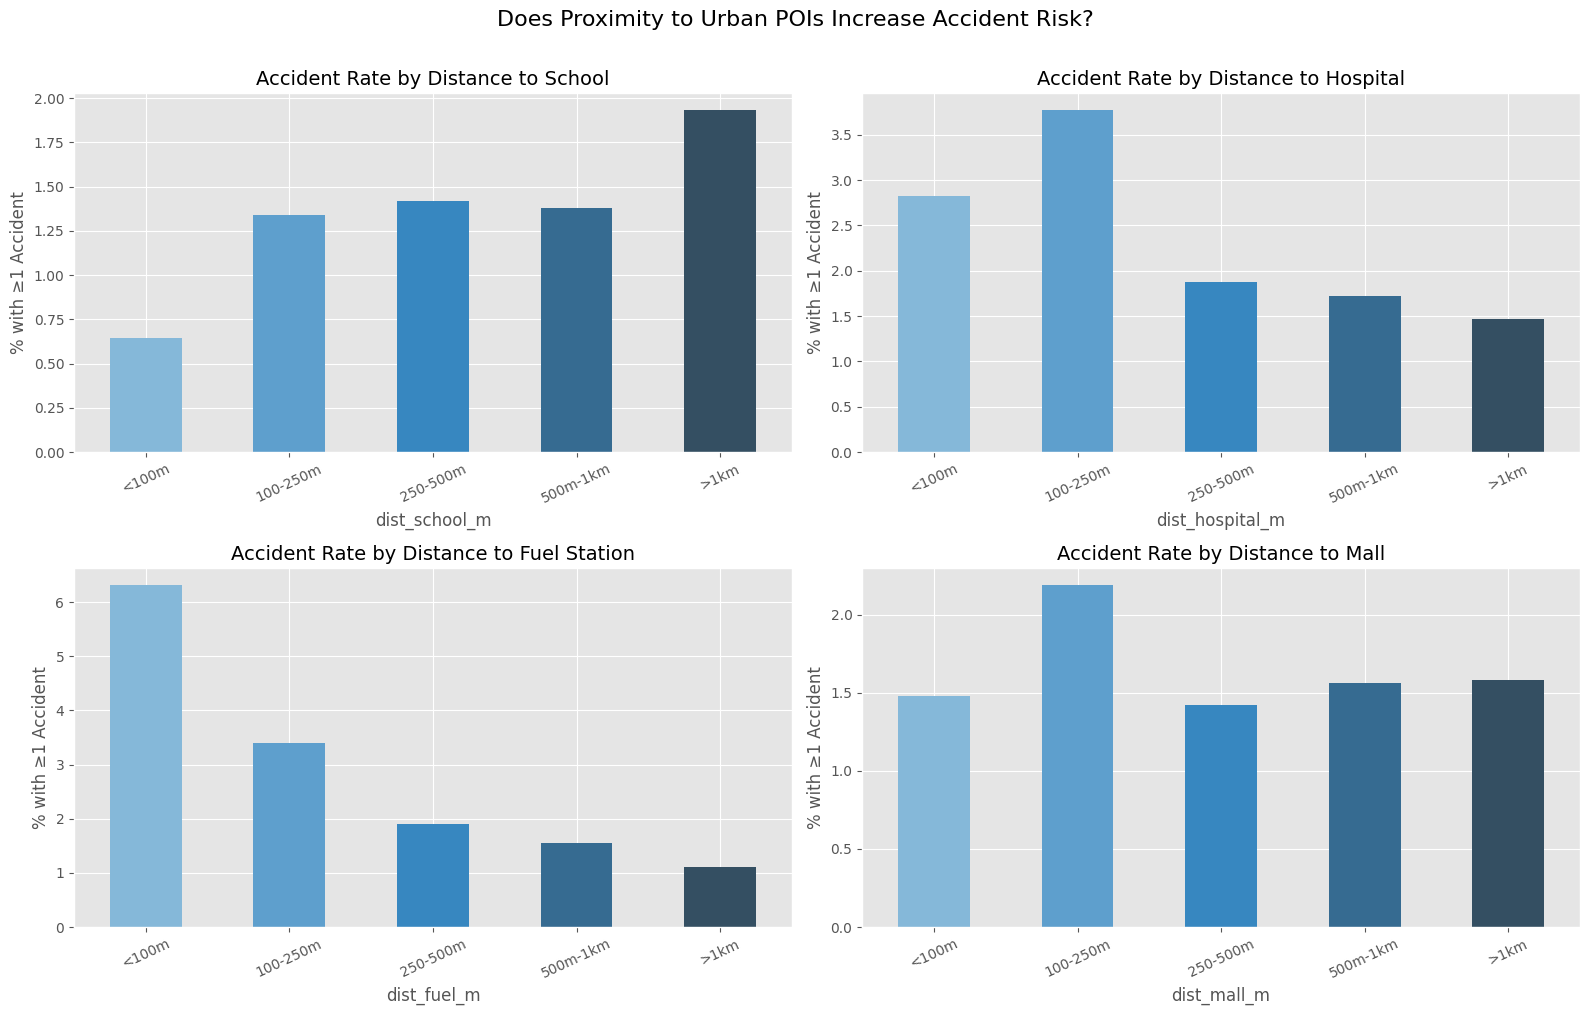

In [11]:
# 3-C: Proximity to dangerous POI types (school, hospital, mall, fuel)
poi_dist_cols = ['dist_school_m', 'dist_hospital_m', 'dist_fuel_m', 'dist_mall_m']
labels = ['School', 'Hospital', 'Fuel Station', 'Mall']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, (col, label) in enumerate(zip(poi_dist_cols, labels)):
    bins = pd.cut(df[col], bins=[0,100,250,500,1000,15000],
                  labels=['<100m','100-250m','250-500m','500m-1km','>1km'])
    rate = df.groupby(bins, observed=True)['has_accident'].mean() * 100
    rate.plot(kind='bar', ax=axes[i], color=sns.color_palette('Blues_d', 5))
    axes[i].set_title(f'Accident Rate by Distance to {label}')
    axes[i].set_ylabel('% with ≥1 Accident')
    axes[i].tick_params(axis='x', rotation=25)

plt.suptitle('Does Proximity to Urban POIs Increase Accident Risk?', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

---
## Part 4 — 🚗 Probe / Speed Features
*(probe_count, speed_mean, speed_std, speed_p10, speed_p90, pct_below_20kmh)*

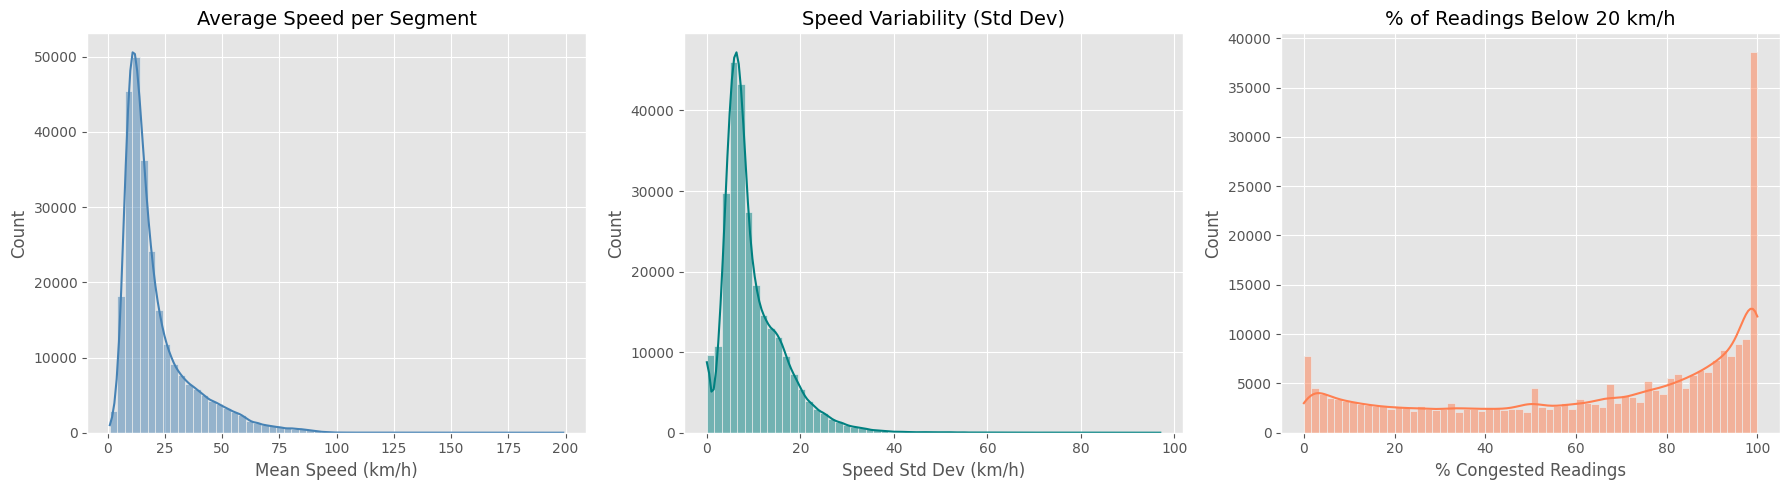

Segments with probe data: 263,460 / 276,062 (95.4%)
Mean speed (Bangkok-wide): 20.8 km/h
Avg congestion (pct<20): 63.3%


In [12]:
# 4-A: Speed distribution overview
probe_df = df[df['has_probe']].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(probe_df['speed_mean'], bins=60, ax=axes[0], color='steelblue', kde=True)
axes[0].set_title('Average Speed per Segment')
axes[0].set_xlabel('Mean Speed (km/h)')

sns.histplot(probe_df['speed_std'], bins=60, ax=axes[1], color='teal', kde=True)
axes[1].set_title('Speed Variability (Std Dev)')
axes[1].set_xlabel('Speed Std Dev (km/h)')

sns.histplot(probe_df['pct_below_20kmh'], bins=60, ax=axes[2], color='coral', kde=True)
axes[2].set_title('% of Readings Below 20 km/h')
axes[2].set_xlabel('% Congested Readings')

plt.tight_layout()
plt.show()

print(f"Segments with probe data: {len(probe_df):,} / {len(df):,} ({len(probe_df)/len(df)*100:.1f}%)")
print(f"Mean speed (Bangkok-wide): {probe_df['speed_mean'].mean():.1f} km/h")
print(f"Avg congestion (pct<20): {probe_df['pct_below_20kmh'].mean():.1f}%")

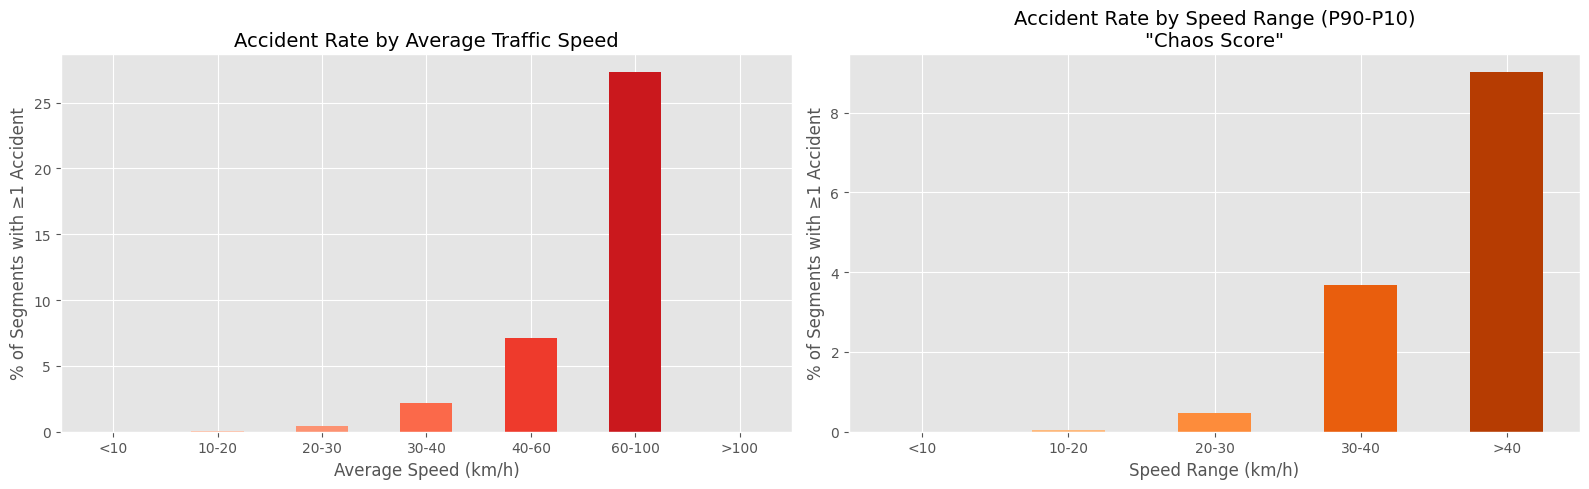

In [13]:
# 4-B: Speed vs Accident risk
# Bin speed_mean and calculate accident rate
probe_df['speed_bin'] = pd.cut(probe_df['speed_mean'], 
                                bins=[0,10,20,30,40,60,100,200],
                                labels=['<10','10-20','20-30','30-40','40-60','60-100','>100'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

speed_acc = probe_df.groupby('speed_bin', observed=True)['has_accident'].mean() * 100
speed_acc.plot(kind='bar', ax=axes[0], color=sns.color_palette('Reds', len(speed_acc)))
axes[0].set_title('Accident Rate by Average Traffic Speed')
axes[0].set_ylabel('% of Segments with ≥1 Accident')
axes[0].set_xlabel('Average Speed (km/h)')
axes[0].tick_params(axis='x', rotation=0)

# Speed P10 vs P90 spread (congestion chaos)
probe_df['speed_range'] = probe_df['speed_p90'] - probe_df['speed_p10']
df_bin = pd.cut(probe_df['speed_range'], bins=[0,10,20,30,40,100],
                labels=['<10','10-20','20-30','30-40','>40'])
range_acc = probe_df.groupby(df_bin, observed=True)['has_accident'].mean() * 100
range_acc.plot(kind='bar', ax=axes[1], color=sns.color_palette('Oranges', 5))
axes[1].set_title('Accident Rate by Speed Range (P90-P10)\n"Chaos Score"')
axes[1].set_ylabel('% of Segments with ≥1 Accident')
axes[1].set_xlabel('Speed Range (km/h)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

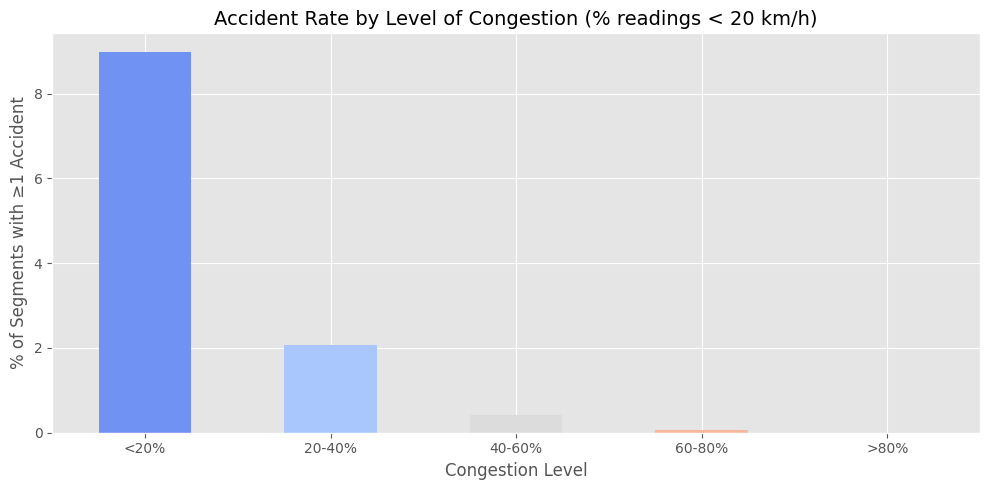

In [14]:
# 4-C: Congestion level vs accident risk
probe_df['congestion_bin'] = pd.cut(probe_df['pct_below_20kmh'],
                                     bins=[0,20,40,60,80,100],
                                     labels=['<20%','20-40%','40-60%','60-80%','>80%'])

fig, ax = plt.subplots(figsize=(10, 5))
cong_acc = probe_df.groupby('congestion_bin', observed=True)['has_accident'].mean() * 100
cong_acc.plot(kind='bar', ax=ax, color=sns.color_palette('coolwarm', 5))
ax.set_title('Accident Rate by Level of Congestion (% readings < 20 km/h)')
ax.set_ylabel('% of Segments with ≥1 Accident')
ax.set_xlabel('Congestion Level')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

---
## Part 5 — 🔗 Cross-Feature Correlations
*Understanding what drives accidents from a modeling perspective*

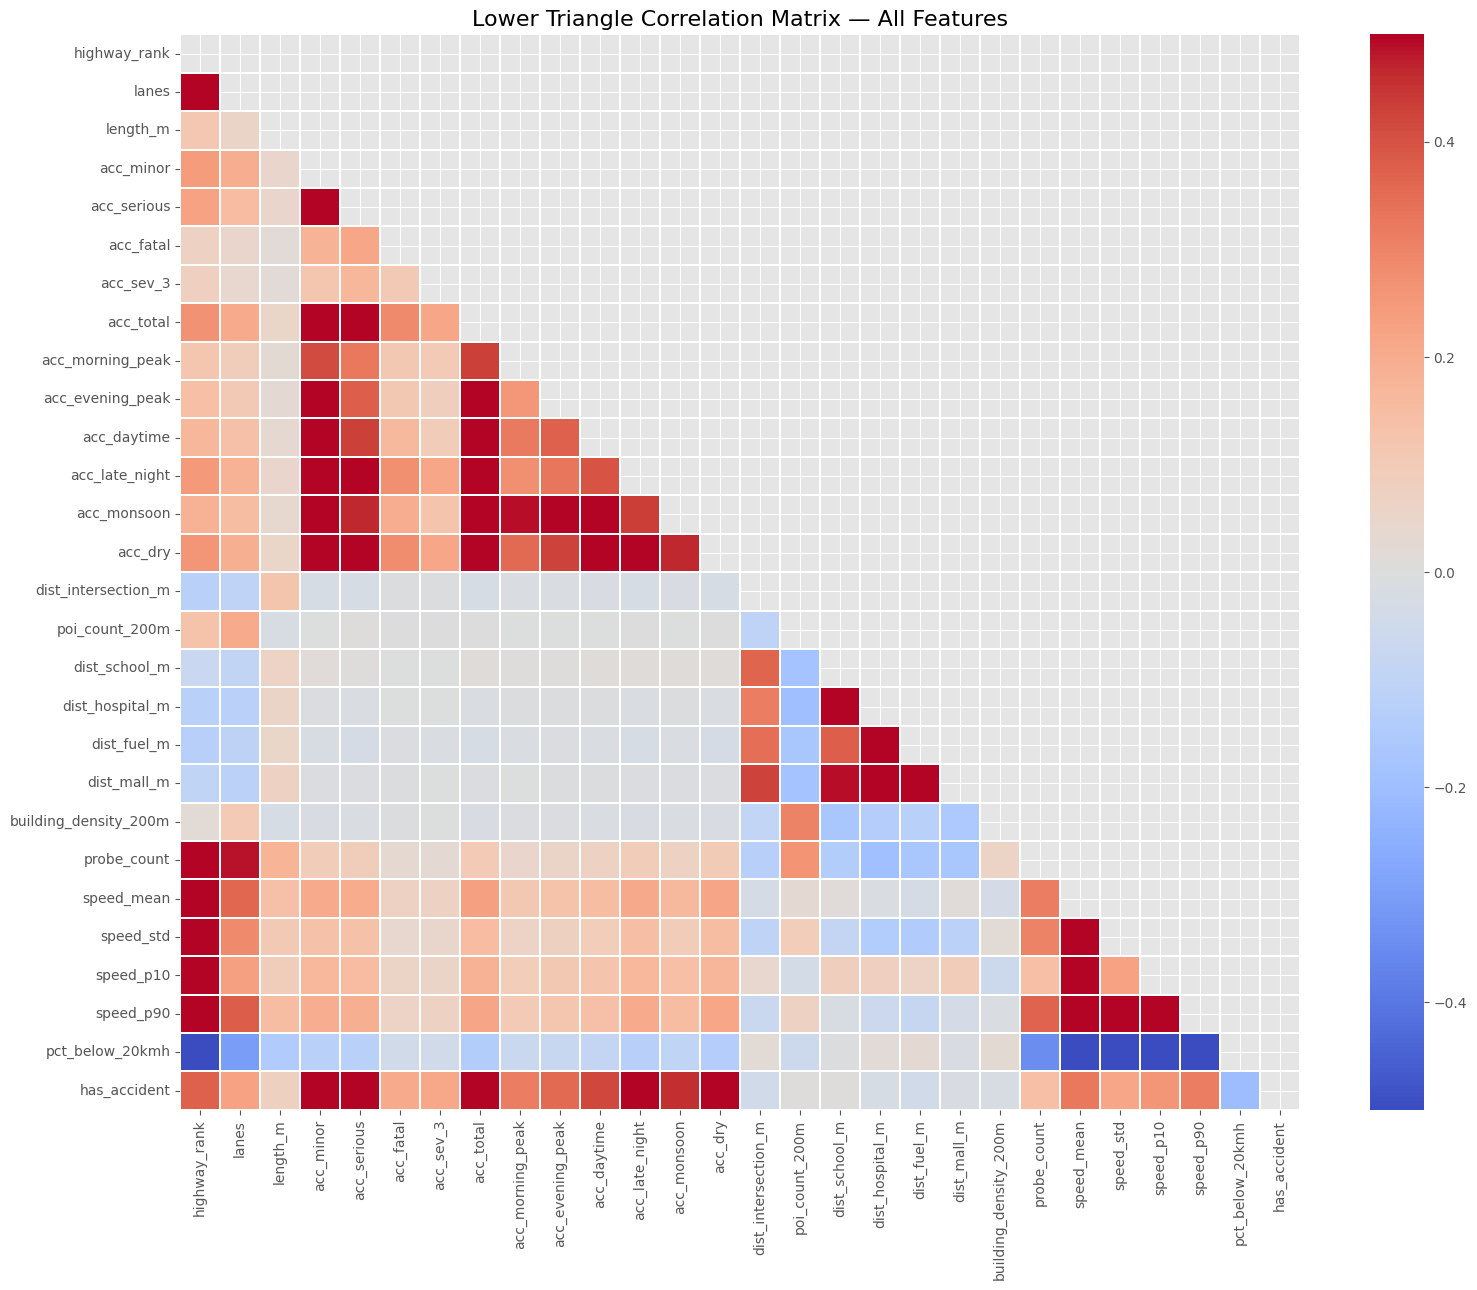

In [15]:
# 5-A: Full correlation heatmap
numeric = df.select_dtypes(include=[np.number]).drop(columns=['segment_id'])
corr = numeric.corr()

plt.figure(figsize=(16, 13))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, annot=False,
            linewidths=0.3, vmin=-0.5, vmax=0.5)
plt.title('Lower Triangle Correlation Matrix — All Features', fontsize=16)
plt.tight_layout()
plt.show()

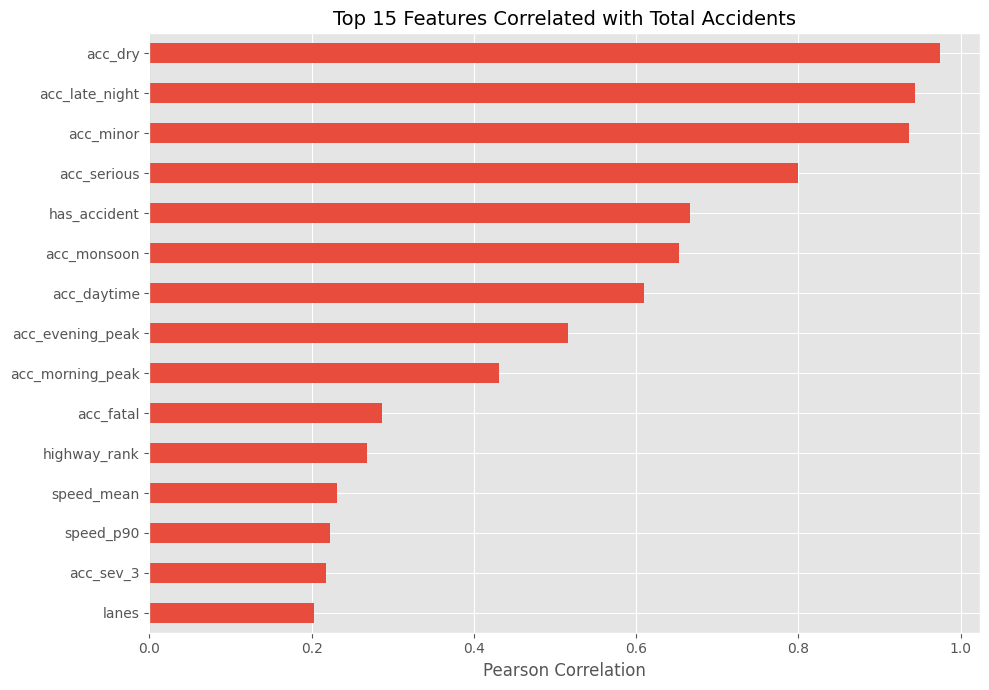

Top 10 correlated features:
acc_dry             0.9751
acc_late_night      0.9435
acc_minor           0.9360
acc_serious         0.7998
has_accident        0.6664
acc_monsoon         0.6525
acc_daytime         0.6099
acc_evening_peak    0.5162
acc_morning_peak    0.4307
acc_fatal           0.2871
Name: acc_total, dtype: float64


In [16]:
# 5-B: Top 15 features by correlation with acc_total
target_corr = corr['acc_total'].drop('acc_total').sort_values(key=abs, ascending=False).head(15)

plt.figure(figsize=(10, 7))
colors = ['#e74c3c' if v > 0 else '#2980b9' for v in target_corr]
target_corr.sort_values().plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 15 Features Correlated with Total Accidents')
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

print('Top 10 correlated features:')
print(target_corr.head(10).round(4))

In [17]:
# 5-C: Modeling readiness summary
print('='*55)
print('  MODELING READINESS SUMMARY')
print('='*55)
print(f'  Total segments          : {len(df):,}')
print(f'  With accidents (>=1)    : {df["has_accident"].sum():,} ({df["has_accident"].mean()*100:.1f}%)')
print(f'  With probe data         : {df["has_probe"].sum():,} ({df["has_probe"].mean()*100:.1f}%)')
print(f'  Missing speed data      : {df["speed_mean"].isna().sum():,} ({df["speed_mean"].isna().mean()*100:.1f}%)')
print()
print('  CLASS IMBALANCE: Recommend class_weight="balanced" or SMOTE')
print('  MISSING DATA   : Impute speed cols per highway type')
print('  OUTLIERS       : acc_total has heavy tail — use log(1+x) transform')
print('='*55)

  MODELING READINESS SUMMARY
  Total segments          : 276,062
  With accidents (>=1)    : 4,385 (1.6%)
  With probe data         : 263,460 (95.4%)
  Missing speed data      : 12,602 (4.6%)

  CLASS IMBALANCE: Recommend class_weight="balanced" or SMOTE
  MISSING DATA   : Impute speed cols per highway type
  OUTLIERS       : acc_total has heavy tail — use log(1+x) transform
